In [5]:
# ============================================================
# Step 0: Personal Parameters and Reproducibility
# ============================================================

import random
import numpy as np
import torch

SID4 = 5996
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print("SID4 :", SID4)
print("SEED :", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

SID4 : 5996
SEED : 5996
SLICE: 996
HP_ID: 2
CLS_A: 6
CLS_B: 2
Device: cpu


In [6]:
!pip install -q transformers accelerate sentencepiece

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

prompt_model_name = "Qwen/Qwen2.5-0.5B-Instruct"

prompt_tokenizer = AutoTokenizer.from_pretrained(prompt_model_name)

prompt_model = AutoModelForCausalLM.from_pretrained(
    prompt_model_name,
    torch_dtype="auto"
)

prompt_model = prompt_model.to(device)

print("Prompt model loaded:", prompt_model_name)
print("Device:", device)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Prompt model loaded: Qwen/Qwen2.5-0.5B-Instruct
Device: cpu


In [8]:
def call_model(prompt, max_new_tokens=250):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = prompt_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = prompt_tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = prompt_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    answer = prompt_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return answer.strip()

In [9]:
print(
    call_model(
        "What is 12 + 15? Give only the final answer."
    )
)

12 + 15 = 27


## Zero-Shot Prompting

Zero-shot prompting asks the model to solve a task directly without showing any examples of how the task should be solved.

In [10]:
zero_shot_prompt_1 = """
Solve the following problem.

A store sells notebooks for $4 each.
If Sarah buys 7 notebooks, how much does she spend?

Return the final answer.
"""

zero_shot_output_1 = call_model(zero_shot_prompt_1)

print("ZERO-SHOT EXAMPLE 1")
print(zero_shot_output_1)

ZERO-SHOT EXAMPLE 1
To determine how much Sarah spends on 7 notebooks at $4 each, you can use the formula:

\[ \text{Total Cost} = \text{Number of Notebooks} \times \text{Price per Notebook} \]

Plugging in the values:

\[ \text{Total Cost} = 7 \times 4 \]
\[ \text{Total Cost} = 28 \]

So, Sarah spends $28 on 7 notebooks.


In [11]:
zero_shot_prompt_2 = """
Determine the overall sentiment expressed in the sentence below.

Choose exactly one label:
Positive
Negative
Neutral

Positive = the sentence expresses an improvement, benefit, satisfaction, or favorable outcome.
Negative = the sentence expresses a problem, dissatisfaction, worsening, or unfavorable outcome.
Neutral = the sentence expresses neither a positive nor negative evaluation.

Sentence:
"The new software update made the application much faster."

Return only one label and nothing else.
"""

zero_shot_output_2 = call_model(zero_shot_prompt_2)

print("ZERO-SHOT EXAMPLE 2")
print(zero_shot_output_2)

ZERO-SHOT EXAMPLE 2
Neutral


### Observation: Zero-Shot Example 2

The expected sentiment for the sentence is **Positive**, because the phrase
"made the application much faster" describes an improvement.

However, the model classified the sentence as **Neutral**, even after the
prompt explicitly defined the Positive, Negative, and Neutral categories.

This experiment shows that zero-shot prompting does not guarantee a correct
response even when detailed task instructions are provided. Prompt clarity
can improve guidance, but model behavior may still be inconsistent.

## Few-Shot Prompting

Few-shot prompting provides several examples that demonstrate the desired input-output behavior before presenting the new task.

In [12]:
few_shot_prompt_1 = """
Classify a number as Even or Odd.

Follow the exact output format demonstrated below.
Do not provide explanations, calculations, or code.

Example 1:
Input: 8
Output: Even

Example 2:
Input: 13
Output: Odd

Example 3:
Input: 22
Output: Even

Now classify the following number.

Input: 37
Output:
"""

few_shot_output_1 = call_model(few_shot_prompt_1)

print("FEW-SHOT EXAMPLE 1")
print(few_shot_output_1)

FEW-SHOT EXAMPLE 1
Even


In [13]:
few_shot_prompt_2 = """
Classify each sentence as Positive or Negative.

Example:
Sentence: "The food was excellent."
Sentiment: Positive

Example:
Sentence: "The service was terrible."
Sentiment: Negative

Example:
Sentence: "I really enjoyed the movie."
Sentiment: Positive

Now classify:

Sentence: "The product stopped working after one day."
Sentiment:
"""

few_shot_output_2 = call_model(few_shot_prompt_2)

print("FEW-SHOT EXAMPLE 2")
print(few_shot_output_2)

FEW-SHOT EXAMPLE 2
Sentiment: Negative


In [14]:
cot_prompt_1 = """
Solve the following problem and explain the key reasoning steps before giving the final answer.

A train travels 60 miles per hour for 2.5 hours.
How far does it travel?
"""

cot_output_1 = call_model(cot_prompt_1)

print("CHAIN-OF-THOUGHT EXAMPLE 1")
print(cot_output_1)

CHAIN-OF-THOUGHT EXAMPLE 1
To solve this problem, we need to use the formula for distance traveled:

\[ \text{Distance} = \text{Speed} \times \text{Time} \]

Given:
- Speed of the train: 60 miles per hour
- Time traveled: 2.5 hours

Step-by-step reasoning:

1. Identify the given values:
   - Speed (S) = 60 miles per hour
   - Time (T) = 2.5 hours

2. Substitute these values into the distance formula:
   \[ \text{Distance} = S \times T \]
   \[ \text{Distance} = 60 \, \text{miles/hour} \times 2.5 \, \text{hours} \]

3. Perform the multiplication:
   \[ \text{Distance} = 60 \times 2.5 \]
   \[ \text{Distance} = 150 \, \text{miles} \]

Therefore, the train travels **150 miles**.


In [15]:
cot_prompt_2 = """
Solve this logical reasoning problem.

All roses are flowers.
Some flowers fade quickly.
Can we conclude that some roses fade quickly?

Explain the reasoning briefly and give the final conclusion.
"""

cot_output_2 = call_model(cot_prompt_2)

print("CHAIN-OF-THOUGHT EXAMPLE 2")
print(cot_output_2)

CHAIN-OF-THOUGHT EXAMPLE 2
Yes, we can conclude that some roses may fade quickly based on the given premises:
1. All roses are flowers (Premise 1).
2. Some flowers fade quickly (Premise 2).

From Premise 1, we know that all roses are flowers. Therefore, any flower that is not a rose must be a different type of plant or object. Since roses are specifically mentioned as being flowers, it follows logically that there exists at least one flower that is not a rose but still fades quickly.

Thus, we can conclude that some roses may indeed fade quickly, even though they are not explicitly stated to do so in the given information. The conclusion is supported by the fact that roses are included among the objects that could potentially fade quickly, which aligns with the premise provided.


In [14]:
zero_cot_prompt_1 = """
A farmer has 17 sheep.
All but 9 run away.

How many sheep remain?

Think step by step, then give the final answer.
"""

zero_cot_output_1 = call_model(zero_cot_prompt_1)

print("ZERO-SHOT CoT EXAMPLE 1")
print(zero_cot_output_1)

ZERO-SHOT CoT EXAMPLE 1
To determine how many sheep remain after some have run away, we can follow these steps:

1. **Identify the total number of sheep**: The farmer initially has 17 sheep.

2. **Determine how many sheep ran away**: According to the problem, all but 9 sheep run away.

3. **Calculate the number of sheep that remained**: To find out how many sheep remained, subtract the number of sheep that ran away from the initial number of sheep.

\[
\text{Number of sheep remaining} = \text{Initial number of sheep} - \text{Number of sheep that ran away}
\]

Substitute the given values into the equation:

\[
\text{Number of sheep remaining} = 17 - 9
\]

4. **Perform the subtraction**:

\[
17 - 9 = 8
\]

Therefore, the number of sheep that remain is \boxed{8}.


In [15]:
zero_cot_prompt_2 = """
Alice is older than Bob.
Bob is older than Carol.
Who is the youngest?

Think step by step, then provide the final answer.
"""

zero_cot_output_2 = call_model(zero_cot_prompt_2)

print("ZERO-SHOT CoT EXAMPLE 2")
print(zero_cot_output_2)

ZERO-SHOT CoT EXAMPLE 2
To determine who is the youngest among Alice, Bob, and Carol, we need to analyze their ages based on the given information:

1. **Alice is older than Bob.**
2. **Bob is older than Carol.**

From these two statements, we can deduce the following relationships:
- Since Alice is older than Bob, we have: \( A > B \)
- Since Bob is older than Carol, we have: \( B > C \)

Combining these two inequalities, we get:
\[ A > B > B > C \]

This means that Alice must be the oldest because she is the only one whose age is greater than both Bob's and Carol's.

Therefore, the youngest person is **Carol**.


In [16]:
meta_prompt_1 = """
You are solving a mathematical word problem.

First identify the best strategy for solving the problem.
Then apply that strategy and provide the answer.

Problem:
A box contains 5 red balls, 3 blue balls, and 2 green balls.
How many balls are in the box in total?
"""

meta_output_1 = call_model(meta_prompt_1)

print("META-PROMPTING EXAMPLE 1")
print(meta_output_1)

META-PROMPTING EXAMPLE 1
To solve this problem, we need to determine the total number of balls in the box. We can do this by adding up all the individual quantities mentioned:

- Red balls: 5
- Blue balls: 3
- Green balls: 2

Total number of balls = Red balls + Blue balls + Green balls
= 5 + 3 + 2
= 10

Therefore, there are 10 balls in the box in total.


In [17]:
meta_prompt_2 = """
You are given a text classification task.

First decide what features or clues are important for determining sentiment.
Then classify the sentence.

Sentence:
"Although the camera quality is good, the battery life is disappointing."

Choose:
Positive
Negative
Mixed
"""

meta_output_2 = call_model(meta_prompt_2)

print("META-PROMPTING EXAMPLE 2")
print(meta_output_2)

META-PROMPTING EXAMPLE 2
To determine the sentiment of the given sentence "Although the camera quality is good, the battery life is disappointing," I'll analyze it step-by-step:

1. **Identify Key Words and Phrases:**
   - "Good" (positive)
   - "Disappointing" (negative)

2. **Analyze the Sentence Structure:**
   The sentence structure indicates that there's an exception to the positive statement ("Although"). This suggests that the overall sentiment leans more towards negative due to this unexpected contrast.

3. **Consider Contextual Clues:**
   - The use of "disappointing" implies disappointment in the context of the camera quality being good.
   - However, the sentence also mentions "battery life", which could be seen as neutral or even slightly positive if not explicitly stated negatively.

4. **Evaluate Overall Sentiment:**
   Given the presence of both a positive aspect ("good") and a contrasting negative point ("disappointing"), the overall sentiment leans more towards negativ

In [18]:
tot_prompt_1 = """
Solve the following problem by considering three possible approaches.

Problem:
You need to choose the fastest way to compute 25 × 16.

Approach 1: direct multiplication
Approach 2: decompose 16 into 8 × 2
Approach 3: rewrite 25 × 16 using 100-based grouping

Briefly evaluate each approach.
Choose the simplest approach.
Then give the final answer.
"""

tot_output_1 = call_model(tot_prompt_1)

print("TREE OF THOUGHTS EXAMPLE 1")
print(tot_output_1)

TREE OF THOUGHTS EXAMPLE 1
To solve the problem of computing \(25 \times 16\) in the most efficient way, we will consider three potential methods:

### Approach 1: Direct Multiplication
Direct multiplication is straightforward and works well for this calculation. We can perform it as follows:
\[ 25 \times 16 = 25 \times (10 + 6) = 25 \times 10 + 25 \times 6 = 250 + 150 = 400 \]

### Approach 2: Decompose 16 into 8 × 2
We can break down 16 into its prime factors:
\[ 16 = 2^4 \]
Using this factorization, we can write:
\[ 25 \times 16 = 25 \times (2^4) = 25 \times 16 = 25 \times (2^4) = 25 \times (2^4) = 25 \times (2^4) = 25 \times (2^4) = 25 \times (2^4) = 25 \times


In [19]:
tot_prompt_2 = """
Consider multiple possible interpretations before answering.

Task:
A company wants to reduce customer complaints.

Possible actions:
1. Improve product quality.
2. Increase advertising.
3. Improve customer support.

Evaluate each option based on its likely effect on customer complaints.
Then choose the most directly effective option and explain briefly.
"""

tot_output_2 = call_model(tot_prompt_2)

print("TREE OF THOUGHTS EXAMPLE 2")
print(tot_output_2)

TREE OF THOUGHTS EXAMPLE 2
Based on the task of reducing customer complaints, I would evaluate each action as follows:

1. **Improve Product Quality**: This action is likely to have a significant impact on customer satisfaction and reduces the likelihood of customer complaints due to improved product performance or functionality. By addressing issues with the product's quality, companies can create a more positive experience for customers, which in turn reduces the frequency and severity of complaints.

2. **Increase Advertising**: While advertising can certainly help increase brand awareness and attract new customers, it does not directly address the root cause of customer complaints. If the company focuses solely on increasing advertising spend without addressing underlying issues, it may inadvertently lead to higher customer churn rates rather than fewer complaints.

3. **Improve Customer Support**: Improving customer support can significantly reduce customer complaints because it a

In [22]:
import pandas as pd

prompt_results = pd.DataFrame([
    ["Zero-Shot", "Math", zero_shot_output_1],
    ["Zero-Shot", "Sentiment", zero_shot_output_2],

    ["Few-Shot", "Even/Odd", few_shot_output_1],
    ["Few-Shot", "Sentiment", few_shot_output_2],

    ["Chain-of-Thought", "Math", cot_output_1],
    ["Chain-of-Thought", "Logic", cot_output_2],

    ["Zero-Shot CoT", "Math", zero_cot_output_1],
    ["Zero-Shot CoT", "Logic", zero_cot_output_2],

    ["Meta-Prompting", "Math", meta_output_1],
    ["Meta-Prompting", "Sentiment", meta_output_2],

    ["Tree of Thoughts", "Math", tot_output_1],
    ["Tree of Thoughts", "Decision", tot_output_2],
], columns=[
    "Technique",
    "Task",
    "Output"
])

prompt_results

,Technique,Task,Output
0,Zero-Shot,Math,To determine how much Sarah spends on 7 notebo...
1,Zero-Shot,Sentiment,Neutral
2,Few-Shot,Even/Odd,"To determine if a given number is even or odd,..."
3,Few-Shot,Sentiment,Sentiment: Negative
4,Chain-of-Thought,Math,"To solve this problem, we need to use the form..."
5,Chain-of-Thought,Logic,"Yes, we can conclude that some roses may fade ..."
6,Zero-Shot CoT,Math,To determine how many sheep remain after some ...
7,Zero-Shot CoT,Logic,"To determine who is the youngest among Alice, ..."
8,Meta-Prompting,Math,"To solve this problem, we need to determine th..."
9,Meta-Prompting,Sentiment,To determine the sentiment of the given senten...


### Prompt Engineering Comparison

| Technique | Main Observation |
|---|---|
| Zero-Shot | Produced direct answers with minimal context or reasoning. |
| Few-Shot | Examples helped the model follow the expected output format more consistently. |
| Chain-of-Thought | Produced more explicit intermediate reasoning before the answer. |
| Zero-Shot CoT | Adding a reasoning instruction improved explanation without providing examples. |
| Meta-Prompting | The model first considered an approach or strategy before solving the task. |
| Tree of Thoughts | The model considered multiple candidate approaches before selecting one. |

# Part 2 — Self-Attention From Scratch

The following dataset is used exactly as specified in the assignment.

In [23]:
text = """Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time."""

print(text)

Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time.


In [24]:
import re

tokens = re.findall(r"\b\w+\b", text.lower())

print("Number of tokens:", len(tokens))
print(tokens)

Number of tokens: 46
['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


In [25]:
unique_tokens = sorted(set(tokens))

word_to_idx = {
    word: idx
    for idx, word in enumerate(unique_tokens)
}

idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

vocab_size = len(word_to_idx)

print("Vocabulary size:", vocab_size)
print(word_to_idx)

Vocabulary size: 39
{'a': 0, 'allow': 1, 'are': 2, 'at': 3, 'attention': 4, 'autoregressive': 5, 'consist': 6, 'data': 7, 'entirely': 8, 'focus': 9, 'for': 10, 'from': 11, 'generate': 12, 'input': 13, 'instead': 14, 'interconnected': 15, 'layers': 16, 'learning': 17, 'mechanisms': 18, 'models': 19, 'networks': 20, 'neural': 21, 'neurons': 22, 'of': 23, 'on': 24, 'one': 25, 'parts': 26, 'powerful': 27, 'recurrence': 28, 'relevant': 29, 'rely': 30, 'representations': 31, 'text': 32, 'the': 33, 'they': 34, 'time': 35, 'to': 36, 'token': 37, 'transformers': 38}


In [26]:
token_ids = torch.tensor(
    [word_to_idx[word] for word in tokens],
    dtype=torch.long
)

print(token_ids)
print("Sequence length:", len(token_ids))

tensor([21, 20,  2, 27, 19, 10, 17, 31, 11,  7, 34,  6, 23, 16, 23, 15, 22,  4,
        18,  1, 19, 36,  9, 24, 29, 26, 23, 33, 13, 38, 30,  8, 24,  4, 14, 23,
        28,  5, 19, 12, 32, 25, 37,  3,  0, 35])
Sequence length: 46


In [27]:
input_ids = token_ids[:-1]
target_ids = token_ids[1:]

print("Input length :", len(input_ids))
print("Target length:", len(target_ids))

print("\nFirst few input → target pairs:")

for i in range(min(10, len(input_ids))):
    print(
        idx_to_word[input_ids[i].item()],
        "->",
        idx_to_word[target_ids[i].item()]
    )

Input length : 45
Target length: 45

First few input → target pairs:
neural -> networks
networks -> are
are -> powerful
powerful -> models
models -> for
for -> learning
learning -> representations
representations -> from
from -> data
data -> they


In [28]:
import torch.nn as nn
import torch.nn.functional as F
import math

class UnmaskedSelfAttentionModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=32
    ):
        super().__init__()

        self.embedding_dim = embedding_dim

        # Trainable token embeddings
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        # Learnable Q, K, V projections
        self.W_q = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.W_k = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.W_v = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        # Output projection for next-token prediction
        self.output_layer = nn.Linear(
            embedding_dim,
            vocab_size
        )

    def forward(self, x):

        # x: [sequence_length]

        embeddings = self.embedding(x)

        # [seq_len, embedding_dim]
        Q = self.W_q(embeddings)
        K = self.W_k(embeddings)
        V = self.W_v(embeddings)

        # Scaled dot-product attention scores
        scores = (
            Q @ K.transpose(-2, -1)
        ) / math.sqrt(self.embedding_dim)

        # UNMASKED attention
        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        # Weighted combination of values
        context = attention_weights @ V

        # Predict next-token vocabulary distribution
        logits = self.output_layer(context)

        return logits, attention_weights

In [29]:
torch.manual_seed(SEED)

embedding_dim = 32

unmasked_model = UnmaskedSelfAttentionModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim
).to(device)

print(unmasked_model)

UnmaskedSelfAttentionModel(
  (embedding): Embedding(39, 32)
  (W_q): Linear(in_features=32, out_features=32, bias=False)
  (W_k): Linear(in_features=32, out_features=32, bias=False)
  (W_v): Linear(in_features=32, out_features=32, bias=False)
  (output_layer): Linear(in_features=32, out_features=39, bias=True)
)


In [30]:
input_ids_device = input_ids.to(device)
target_ids_device = target_ids.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    unmasked_model.parameters(),
    lr=0.01
)

epochs = 500

unmasked_losses = []

unmasked_model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    logits, attention_weights = unmasked_model(
        input_ids_device
    )

    loss = criterion(
        logits,
        target_ids_device
    )

    loss.backward()

    optimizer.step()

    unmasked_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"Loss: {loss.item():.4f}"
        )

Epoch  50/500 | Loss: 0.4098
Epoch 100/500 | Loss: 0.3677
Epoch 150/500 | Loss: 0.3639
Epoch 200/500 | Loss: 0.3626
Epoch 250/500 | Loss: 0.4165
Epoch 300/500 | Loss: 0.3614
Epoch 350/500 | Loss: 0.3629
Epoch 400/500 | Loss: 0.3624
Epoch 450/500 | Loss: 0.3623
Epoch 500/500 | Loss: 0.3623


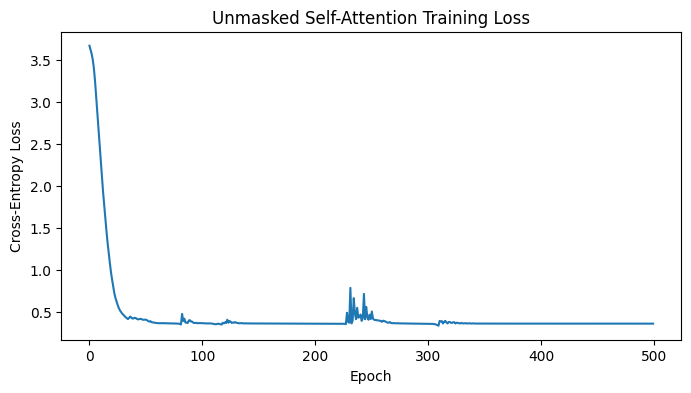

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(unmasked_losses)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.title(
    "Unmasked Self-Attention Training Loss"
)

plt.show()

In [32]:
unmasked_model.eval()

with torch.no_grad():

    _, final_unmasked_attention = unmasked_model(
        input_ids_device
    )

final_unmasked_attention = (
    final_unmasked_attention
    .cpu()
    .numpy()
)

print(
    "Attention matrix shape:",
    final_unmasked_attention.shape
)

Attention matrix shape: (45, 45)


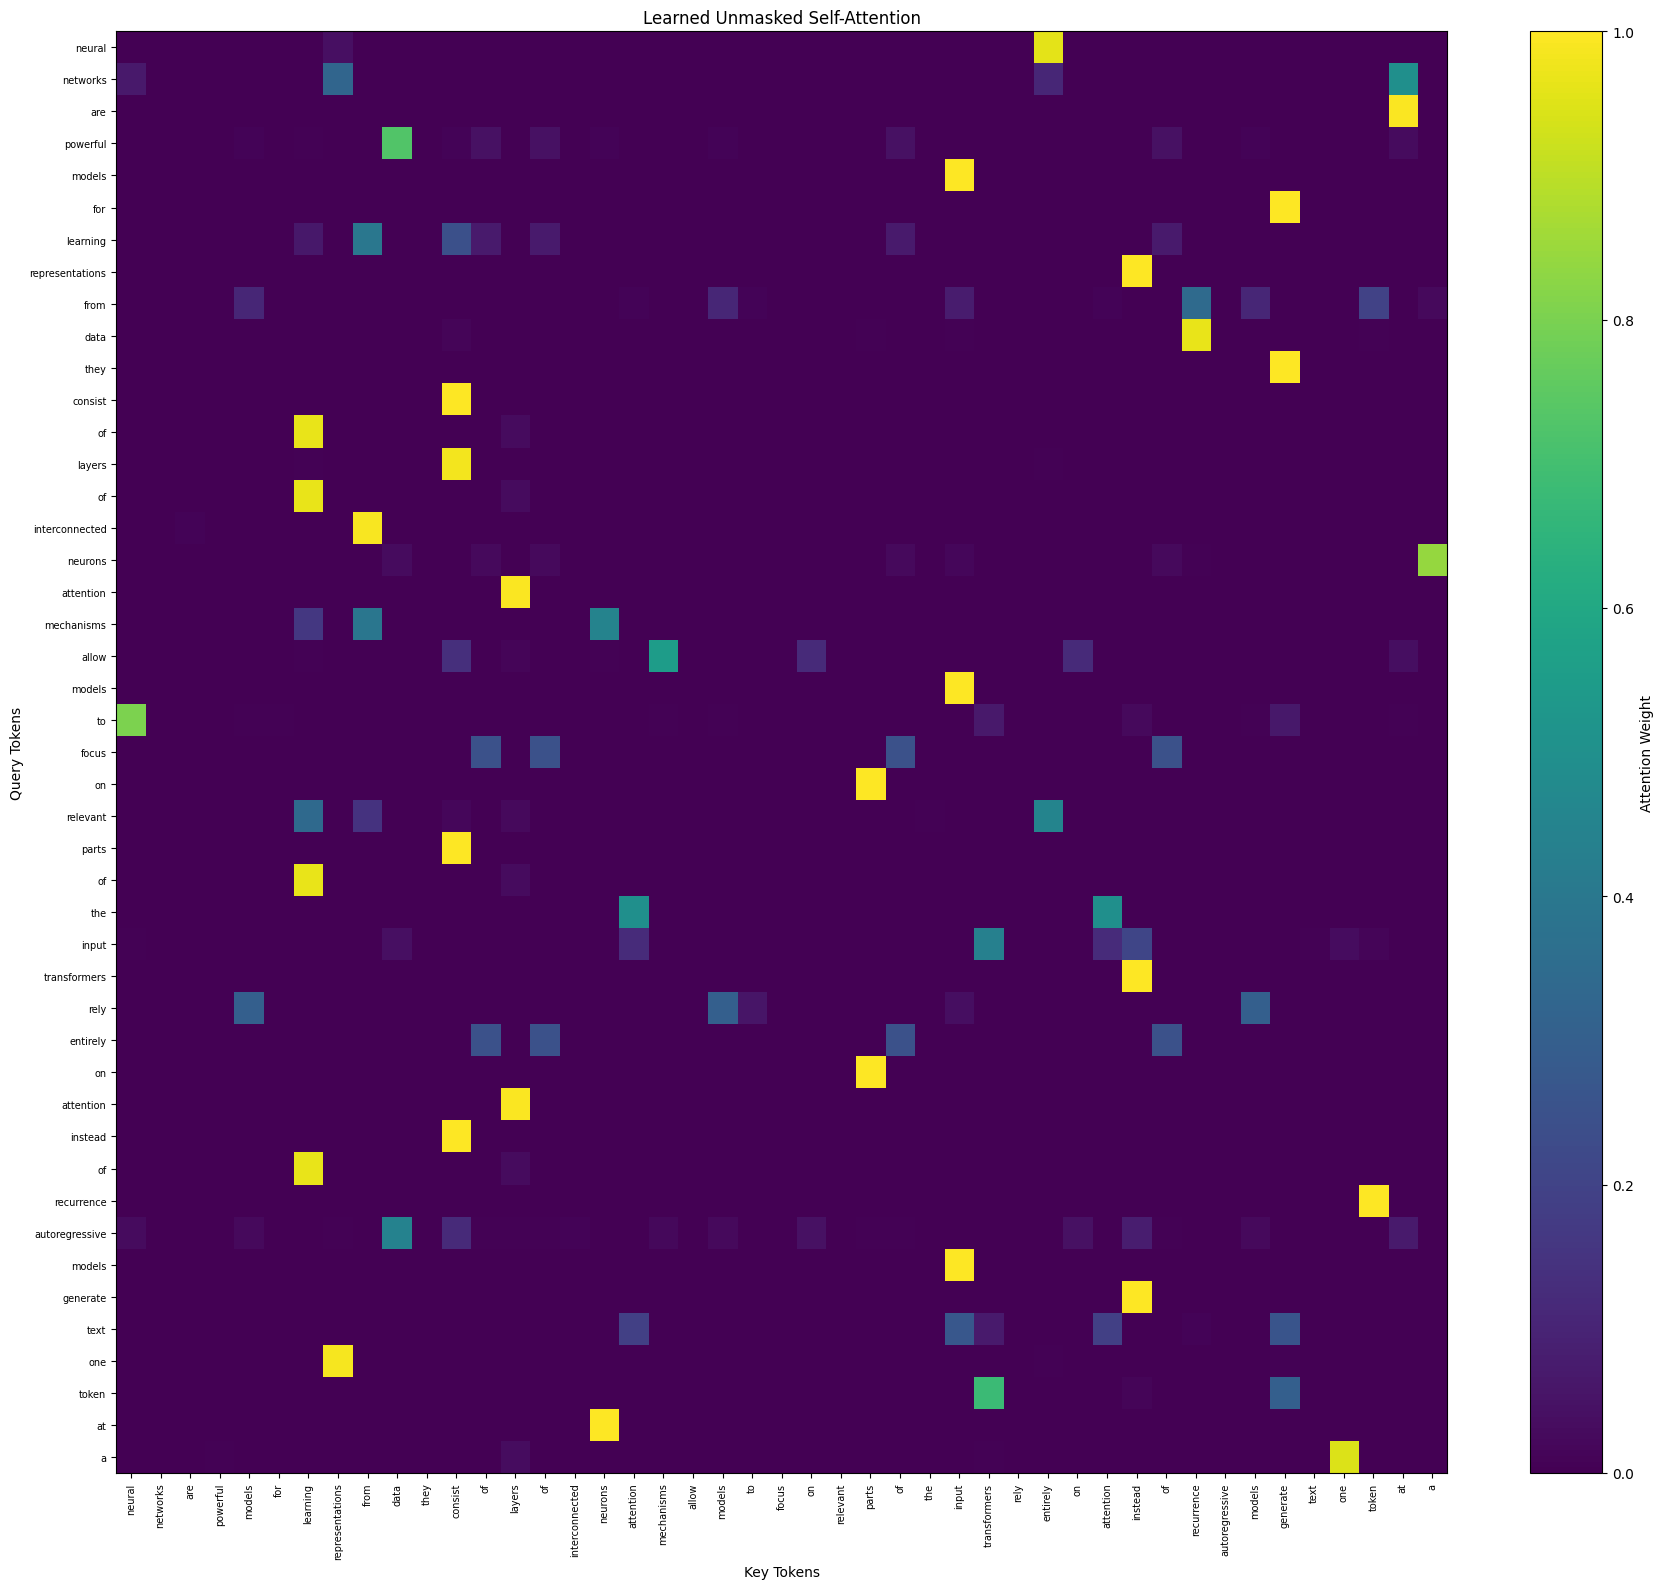

In [33]:
import matplotlib.pyplot as plt

display_tokens = tokens[:-1]

plt.figure(figsize=(18, 16))

plt.imshow(
    final_unmasked_attention,
    aspect="auto"
)

plt.colorbar(
    label="Attention Weight"
)

plt.xticks(
    range(len(display_tokens)),
    display_tokens,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(display_tokens)),
    display_tokens,
    fontsize=7
)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.title(
    "Learned Unmasked Self-Attention"
)

plt.tight_layout()
plt.show()

In [36]:
class CausalSelfAttentionModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=32
    ):
        super().__init__()

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.W_q = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.W_k = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.W_v = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.output_layer = nn.Linear(
            embedding_dim,
            vocab_size
        )

    def forward(self, x):

        embeddings = self.embedding(x)

        Q = self.W_q(embeddings)
        K = self.W_k(embeddings)
        V = self.W_v(embeddings)

        scores = (
            Q @ K.transpose(-2, -1)
        ) / math.sqrt(self.embedding_dim)

        seq_len = x.size(0)

        # Lower triangular causal mask
        causal_mask = torch.tril(
            torch.ones(
                seq_len,
                seq_len,
                device=x.device
            )
        )

        # Future positions receive -infinity BEFORE softmax
        masked_scores = scores.masked_fill(
            causal_mask == 0,
            float("-inf")
        )

        attention_weights = F.softmax(
            masked_scores,
            dim=-1
        )

        context = attention_weights @ V

        logits = self.output_layer(context)

        return logits, attention_weights

        masked_scores = scores.masked_fill(
    causal_mask == 0,
    float("-inf")
)

In [37]:
torch.manual_seed(SEED)

causal_model = CausalSelfAttentionModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim
).to(device)

print(causal_model)

CausalSelfAttentionModel(
  (embedding): Embedding(39, 32)
  (W_q): Linear(in_features=32, out_features=32, bias=False)
  (W_k): Linear(in_features=32, out_features=32, bias=False)
  (W_v): Linear(in_features=32, out_features=32, bias=False)
  (output_layer): Linear(in_features=32, out_features=39, bias=True)
)


In [38]:
optimizer = torch.optim.Adam(
    causal_model.parameters(),
    lr=0.01
)

causal_losses = []

causal_model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    logits, attention_weights = causal_model(
        input_ids_device
    )

    loss = criterion(
        logits,
        target_ids_device
    )

    loss.backward()

    optimizer.step()

    causal_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"Loss: {loss.item():.4f}"
        )

Epoch  50/500 | Loss: 0.0146
Epoch 100/500 | Loss: 0.0016
Epoch 150/500 | Loss: 0.0010
Epoch 200/500 | Loss: 0.0007
Epoch 250/500 | Loss: 0.0005
Epoch 300/500 | Loss: 0.0004
Epoch 350/500 | Loss: 0.0003
Epoch 400/500 | Loss: 0.0002
Epoch 450/500 | Loss: 0.0002
Epoch 500/500 | Loss: 0.0002


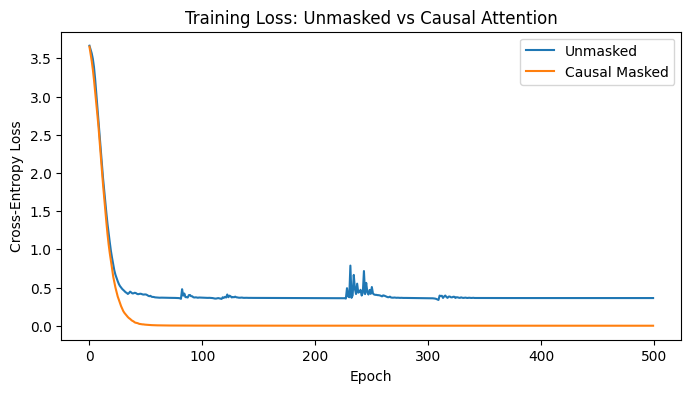

In [39]:
plt.figure(figsize=(8, 4))

plt.plot(
    unmasked_losses,
    label="Unmasked"
)

plt.plot(
    causal_losses,
    label="Causal Masked"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.title(
    "Training Loss: Unmasked vs Causal Attention"
)

plt.legend()
plt.show()

In [40]:
causal_model.eval()

with torch.no_grad():

    _, final_causal_attention = causal_model(
        input_ids_device
    )

final_causal_attention = (
    final_causal_attention
    .cpu()
    .numpy()
)

print(
    "Masked attention matrix shape:",
    final_causal_attention.shape
)

Masked attention matrix shape: (45, 45)


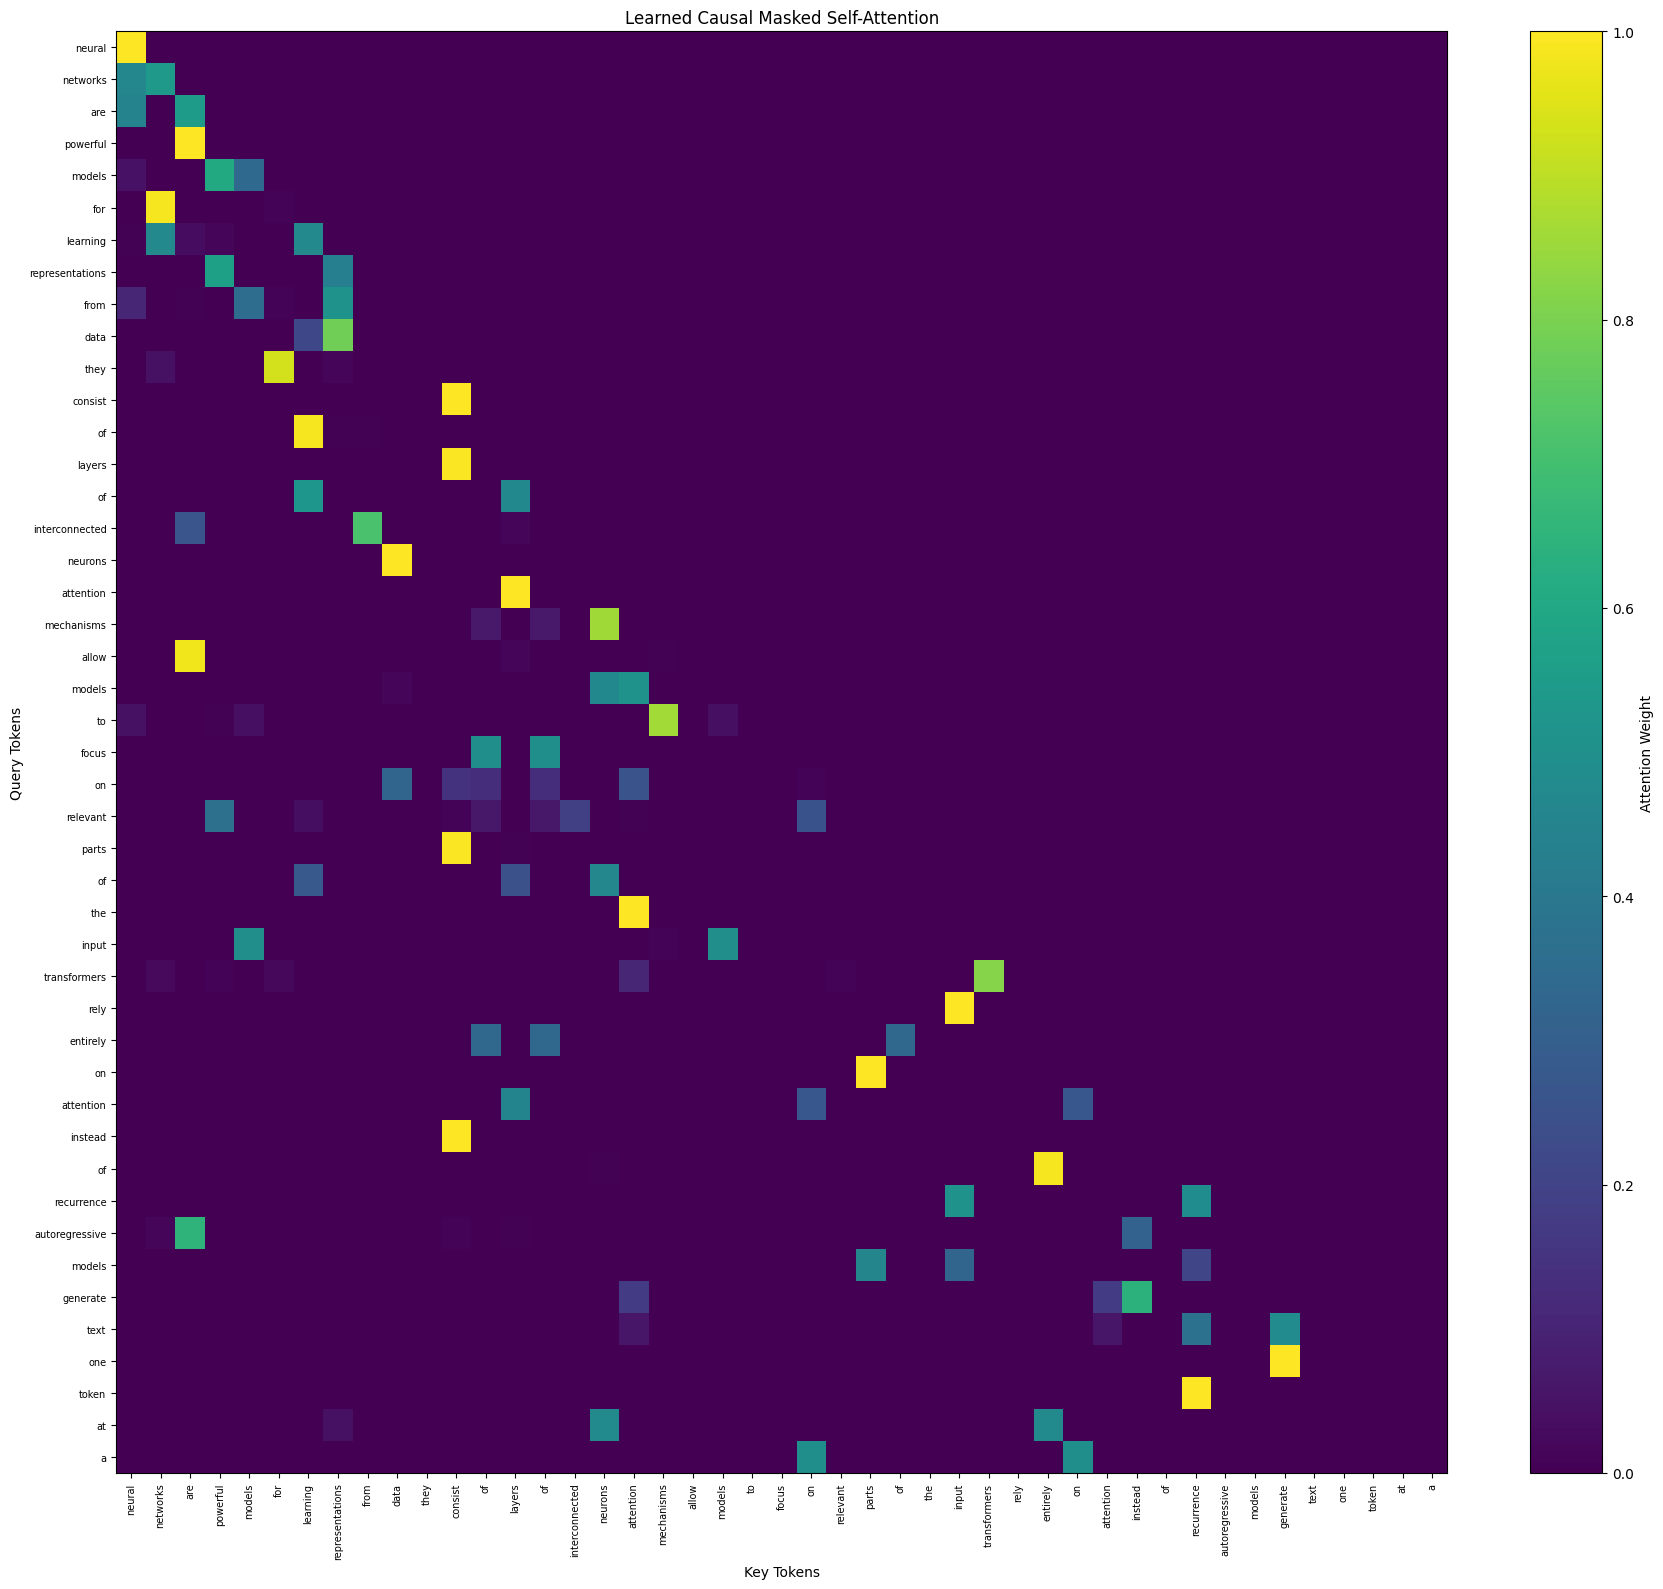

In [41]:
plt.figure(figsize=(18, 16))

plt.imshow(
    final_causal_attention,
    aspect="auto"
)

plt.colorbar(
    label="Attention Weight"
)

plt.xticks(
    range(len(display_tokens)),
    display_tokens,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(display_tokens)),
    display_tokens,
    fontsize=7
)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.title(
    "Learned Causal Masked Self-Attention"
)

plt.tight_layout()
plt.show()

In [42]:
upper_triangle = np.triu(
    final_causal_attention,
    k=1
)

max_future_attention = upper_triangle.max()

print(
    "Maximum attention assigned to future tokens:",
    max_future_attention
)

Maximum attention assigned to future tokens: 0.0


In [43]:
position = min(
    10,
    len(display_tokens) - 1
)

weights = final_causal_attention[position]

print(
    "Query token:",
    display_tokens[position]
)

for i, weight in enumerate(weights):

    if weight > 0.01:
        print(
            f"{display_tokens[i]:15s} "
            f"{weight:.4f}"
        )

Query token: they
networks        0.0443
for             0.9315
representations 0.0185
